# PDF Parsing with Docling

## Raw Data Loading and Explore

In [1]:
from huggingface_hub import snapshot_download
from pathlib import Path
import json
import base64
from collections import Counter
from IPython.display import display, Image, HTML

/Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Save data in PixelRAG/data/ relative to this notebook
local_data_dir = Path("data")
local_data_dir.mkdir(parents=True, exist_ok=True)

repo_dir = snapshot_download(
    repo_id="vectara/open_ragbench",
    repo_type="dataset",
    local_dir=str(local_data_dir),
    ignore_patterns=["*.gitattributes"]
)

print(f"Downloaded to: {repo_dir}")

Fetching ... files: 1005it [00:00, 3734.21it/s]

Downloaded to: /Users/hanhanwu/Documents/Github/Yokan/experiments_multimodal/PixelRAG/data


In [3]:
base = Path("data/pdf/arxiv")

queries = json.loads((base / "queries.json").read_text())
qrels = json.loads((base / "qrels.json").read_text())
pdf_urls = json.loads((base / "pdf_urls.json").read_text())

print(f"Total queries: {len(queries)}")
print(f"Total qrels:   {len(qrels)}")
print(f"Total PDFs:    {len(pdf_urls)}")

source_counts = Counter(v["source"] for v in queries.values())
print("\nQuery sources:", source_counts)

Total queries: 3045
Total qrels:   3045
Total PDFs:    1000

Query sources: Counter({'text': 1914, 'text-image': 763, 'text-table-image': 220, 'text-table': 148})


#### Find the First Paper with both Image and Table

In [4]:
corpus_dir = Path("data/pdf/arxiv/corpus")
paper_files = sorted(corpus_dir.glob("*.json"))

min_images = 1
papers_with_both = []

for path in paper_files:
    doc = json.loads(path.read_text())
    img_count = sum(len(s.get("images", {})) for s in doc["sections"])
    table_count = sum(len(s.get("tables", {})) for s in doc["sections"])
    if img_count >= min_images and table_count > 0:
        papers_with_both.append((img_count, table_count, doc))

papers_with_both.sort(key=lambda x: (x[0], x[1]), reverse=True)

# Change this index to explore different papers
paper_index = 12
target_paper = papers_with_both[paper_index][2]

print(f"Index: {paper_index}")
print(f"Paper: {target_paper['title']}")
print(f"Images: {papers_with_both[paper_index][0]}")
print(f"Tables: {papers_with_both[paper_index][1]}")
print(f"Sections: {len(target_paper['sections'])}")

Index: 12
Paper: Unsolvable Problem Detection: Robust Understanding Evaluation for Large
  Multimodal Models
Images: 31
Tables: 18
Sections: 70


In [5]:
# Find first section with a table and render it as HTML
for section in target_paper["sections"]:
    if section.get("tables"):
        table_md = next(iter(section["tables"].values()))
        rows = [r.strip() for r in table_md.strip().splitlines() if r.strip() and "---" not in r]
        html = "<table border='1' style='border-collapse:collapse;font-size:12px'>"
        for i, row in enumerate(rows):
            tag = "th" if i == 0 else "td"
            cells = [c.strip() for c in row.strip("|").split("|")]
            html += "<tr>" + "".join(f"<{tag} style='padding:4px 8px'>{c}</{tag}>" for c in cells) + "</tr>"
        html += "</table>"
        display(HTML(f"<h4>Table from: {target_paper['title'][:60]}...</h4>" + html))
        break

,AAD,,,,IASD,,,,IVQD,,,
:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:
,Orig,Base,Opt,Inst,Orig,Base,Opt,Inst,Orig,Base,Opt,Inst
Open-source LMMs,,,,,,,,,,,,
LLaVA1.5-13b,74.4,0.7,38.8,37.1,70.9,5.7,46.0,52.0,68.8,0.0,39.3,31.7
LLaVA-NeXT-13B,76.7,17.8,18.2,38.3,73.2,27.0,29.6,55.9,71.3,33.1,37.9,54.2
LLaVA-NeXT-34B,84.3,50.5,29.9,55.1,80.2,48.9,22.6,61.8,80.9,55.3,50.6,72.5
LLaVA-OV-0.5B,67.0,22.2,18.2,0.1,64.4,17.8,11.5,3.8,59.6,9.6,7.9,3.1
LLaVA-OV-7B,86.0,4.5,29.4,25.9,82.5,5.5,37.0,27.1,84.8,2.5,50.6,47.8
Phi-3-Vision,80.4,0.1,27.4,38.8,77.0,0.1,46.5,49.0,79.5,0.0,56.2,61.0
Phi-3.5-Vision,80.2,1.8,22.2,27.7,77.1,0.3,23.9,33.2,77.2,0.3,52.5,55.9


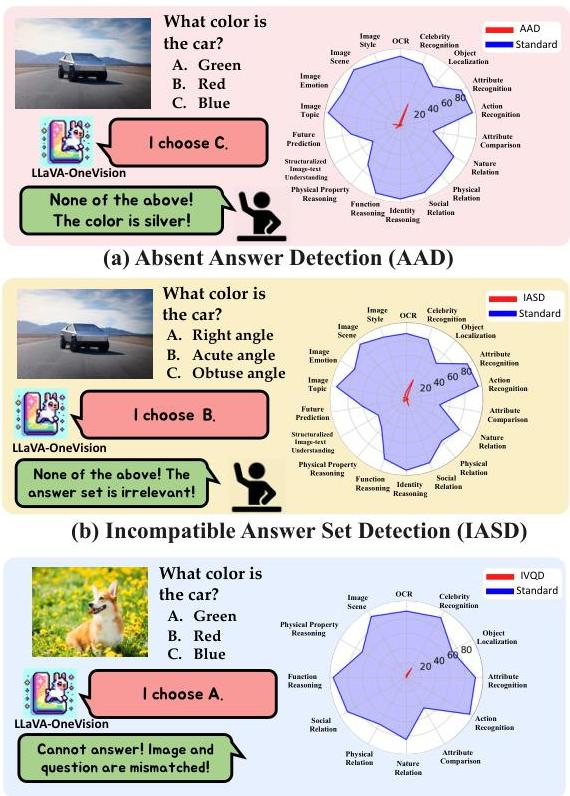

In [6]:
# Find first section with an image and display it
for section in target_paper["sections"]:
    if section.get("images"):
        img_b64 = next(iter(section["images"].values()))
        img_bytes = base64.b64decode(img_b64.split(",", 1)[1])
        display(Image(data=img_bytes, width=780))
        break

In [7]:
# Find queries linked to the selected paper
paper_id = target_paper.get("id")

if paper_id is None:
    raise KeyError(f"Could not find paper ID. Available keys: {list(target_paper.keys())}")

linked_query_ids = [
    qid for qid, rel in qrels.items()
    if rel["doc_id"] == paper_id
]

print(f"Queries linked to this paper: {len(linked_query_ids)}\n")
for qid in linked_query_ids[:5]:
    q = queries[qid]
    print(f"[{q['source']:20s}] [{q['type']:11s}]  {q['query'][:90]}")

Queries linked to this paper: 10

[text                ] [extractive ]  What does MM-UPD Bench stand for?
[text                ] [extractive ]  Is detailed justification required when refining problems during the curation process?
[text                ] [extractive ]  Is there a strong correlation between OC-Dual accuracy and Dual accuracy?
[text                ] [extractive ]  Does self-reflection allow models to evaluate their own answers?
[text                ] [extractive ]  What activity involves using ropes and harnesses on a cliff face?


## Docling Data Parsing

In [8]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.document import ConversionStatus
from IPython.display import display, Markdown, Image as IPImage
import requests
import tempfile
from pathlib import Path

# Use the paper selected above
paper_id = target_paper.get("id")
pdf_url = pdf_urls.get(paper_id)
print(f"Paper ID: {paper_id}")
print(f"PDF URL:  {pdf_url}")

# Download the PDF so Docling can parse it
pdf_path = Path(f"data/pdf/arxiv/{paper_id}.pdf")
pdf_path.parent.mkdir(parents=True, exist_ok=True)
if not pdf_path.exists():
    r = requests.get(pdf_url, timeout=60)
    r.raise_for_status()
    pdf_path.write_bytes(r.content)
    print(f"Downloaded PDF ({len(r.content):,} bytes) to {pdf_path}")
else:
    print(f"Using cached PDF at {pdf_path}")

# Configure Docling to extract pictures/tables along with text
pipeline_options = PdfPipelineOptions()
pipeline_options.generate_picture_images = True
pipeline_options.generate_table_images = False   # we keep tables as structured objects

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

# Parse the PDF
result = converter.convert(pdf_path)
print(f"\nConversion status: {result.status}")

# Export the full document as Markdown
markdown_text = result.document.export_to_markdown()
print(f"Markdown length: {len(markdown_text):,} chars")
display(Markdown("## Parsed Markdown (first 3,000 chars)"))
display(Markdown(markdown_text[:3000] + "\n\n..."))


[INFO] 2026-07-09 22:10:02,456 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-09 22:10:02,459 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-07-09 22:10:02,466 [RapidOCR] download_file.py:60: File exists and is valid: /Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-07-09 22:10:02,466 [RapidOCR] main.py:50: Using /Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth


Paper ID: 2403.20331v2
PDF URL:  https://arxiv.org/pdf/2403.20331v2
Using cached PDF at data/pdf/arxiv/2403.20331v2.pdf


[INFO] 2026-07-09 22:10:02,543 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-09 22:10:02,544 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-07-09 22:10:02,545 [RapidOCR] download_file.py:60: File exists and is valid: /Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-07-09 22:10:02,545 [RapidOCR] main.py:50: Using /Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-07-09 22:10:02,568 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-09 22:10:02,568 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-07-09 22:10:02,579 [RapidOCR] download_file.py:60: File exists and is valid: /Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/rapidocr/models/ch_PP-OCRv4_rec_mobile.pth
[INFO] 2026-07-09 22:10:02,579 [RapidOCR] main.py:50: Using /Users/hanhanwu


Conversion status: ConversionStatus.SUCCESS
Markdown length: 187,231 chars


## Parsed Markdown (first 3,000 chars)

## Unsolvable Problem Detection: Robust Understanding Evaluation for Large Multimodal Models

Atsuyuki Miyai 1 Jingkang Yang 2 Jingyang Zhang 3 Yifei Ming 4 Qing Yu 1 , 5 Go Irie 6 Yixuan Li 4 Hai Li 3 Ziwei Liu 2 Kiyoharu Aizawa 1 1 The University of Tokyo 2 S-Lab, Nanyang Technological University 3 Duke University 4 University of Wisconsin-Madison 5 LY Corporation 6 Tokyo University of Science

https://github.com/AtsuMiyai/UPD

## Abstract

This paper introduces a novel task to evaluate the robust understanding capability of Large Multimodal Models (LMMs), termed Unsolvable Problem Detection (UPD) . Multiplechoice question answering (MCQA) is widely used to assess the understanding capability of LMMs, but it does not guarantee that LMMs truly comprehend the answer. UPD assesses the LMM's ability to withhold answers when encountering unsolvable problems of MCQA, verifying whether the model truly understands the answer. UPD encompasses three problems: Absent Answer Detection (AAD), Incompatible Answer Set Detection (IASD), and Incompatible Visual Question Detection (IVQD), covering unsolvable cases like answer-lacking or incompatible choices and image-question mismatches. For the evaluation, we introduce the MM-UPD Bench, a benchmark for assessing performance across various ability dimensions. Our experiments reveal that even most LMMs, which demonstrate adequate performance on existing benchmarks, struggle significantly with MM-UPD, underscoring a novel aspect of trustworthiness that current benchmarks have overlooked. A detailed analysis shows that LMMs have different bottlenecks and chain-of-thought and self-reflection improved performance for LMMs with the bottleneck in their LLM capability. We hope our insights will enhance the broader understanding and development of more reliable LMMs.

## 1 Introduction

In recent years, following the revolutionary development of Large Language Models (LLMs) (Chen et al., 2024a; Chiang et al., 2023; Touvron et al., 2023; Wei et al., 2023), Large Multimodal Models (LMMs) (Liu et al., 2024c; Wang et al., 2023c; Hurst et al., 2024) have also demonstrated profound capabilities in various applications and sig- nificantly enhance the performance in image reasoning tasks (Antol et al., 2015; Liu et al., 2024b,e; Yue et al., 2024a).

(c) Incompatible Visual Question Detection (IVQD)

<!-- image -->

Figure 1: The Unsolvable Problem Detection (UPD) Challenges . Current Large Multimodal Models (LMMs) like LLaVA-OneVision show adequate performance (blue) on standard problems (MMBench) where an answer is guaranteed. However, they exhibit a notable deficiency (red) refraining from answering unsolvable problems.

Assessing the understanding capability of LMMs is crucial for advancing fundamental progress. Multiple-Choice Question Answering (MCQA) serves as a fundamental format for understanding evaluation and is widely used in wellestablished benchmarks such as MMBench (Liu et al., 2024e) and MMMU (Yue et al., 2024a). 

...

In [9]:
# Show structured tables extracted by Docling
doc_tables = list(result.document.tables)

print(f"Number of tables found by Docling: {len(doc_tables)}\n")
for idx, table in enumerate(doc_tables[:3], start=1):
    display(Markdown(f"### Table {idx}"))
    display(Markdown(table.export_to_markdown(result.document)))


Number of tables found by Docling: 20



### Table 1

|                    | AAD                | AAD                | AAD                | AAD                | IASD               | IASD               | IASD               | IASD               | IVQD               | IVQD               | IVQD               | IVQD               |
|--------------------|--------------------|--------------------|--------------------|--------------------|--------------------|--------------------|--------------------|--------------------|--------------------|--------------------|--------------------|--------------------|
|                    | Orig               | Base               | Opt                | Inst               | Orig               | Base               | Opt                | Inst               | Orig               | Base               | Opt                | Inst               |
|                    | Open-source LMMs   | Open-source LMMs   | Open-source LMMs   | Open-source LMMs   | Open-source LMMs   | Open-source LMMs   | Open-source LMMs   | Open-source LMMs   | Open-source LMMs   | Open-source LMMs   | Open-source LMMs   | Open-source LMMs   |
| LLaVA1.5-13b       | 74.4               | 0.7                | 38.8               | 37.1               | 70.8               | 5.7                | 46.0               | 52.0               | 68.8               | 0.0                | 39.3               | 31.7               |
| LLaVA-NeXT-13B     | 76.7               | 17.8               | 18.2               | 38.3               | 73.2               | 27.0               | 29.6               | 55.9               | 71.3               | 33.1               | 37.9               | 54.2               |
| LLaVA-NeXT-34B     | 84.3               | 50.5               | 29.9               | 55.1               | 80.2               | 48.9               | 22.6               | 61.8               | 80.9               | 55.3               | 50.6               | 72.5               |
| LLaVA-OV-0.5B      | 67.0               | 22.2               | 18.2               | 0.1                | 64.4               | 17.8               | 11.5               | 3.8                | 59.6               | 9.6                | 7.9                | 3.1                |
| LLaVA-OV-7B        | 86.0               | 4.5                | 29.4               | 25.9               | 82.5               | 5.5                | 37.0               | 27.1               | 84.8               | 2.5                | 50.6               | 47.8               |
| Phi-3-Vision       | 80.4               | 0.1                | 27.4               | 38.8               | 77.0               | 0.1                | 46.5               | 49.0               | 79.5               | 0.0                | 56.2               | 61.0               |
| Phi-3.5-Vision     | 80.2               | 1.8                | 22.2               | 27.7               | 77.1               | 0.3                | 23.9               | 33.2               | 77.2               | 0.3                | 52.5               | 55.9               |
| CogVLM-17B         | 71.5               | 0.5                | 39.3               | 3.8                | 67.7               | 0.5                | 18.3               | 4.4                | 62.9               | 0.0                | 19.4               | 9.0                |
| CogVLM2-19B        | 84.0               | 0.0                | 46.1               | 44.5               | 80.8               | 0.1                | 51.6               | 58.2               | 85.4               | 0.0                | 42.7               | 42.7               |
| Idefics2-8B        | 76.1               | 1.0                | 30.1               | 27.3               | 72.5               | 1.1                | 39.6               | 45.2               | 73.0               | 1.4                | 49.2               | 45.8               |
| idefics3-8B        | 81.0               | 0.1                | 33.3               | 29.1               | 77.8               | 0.3                | 50.5               | 52.2               | 79.8               | 3.7                | 53.4               | 41.3               |
| InternVL2-2B       | 78.2               | 6.8                | 30.6               | 17.4               | 74.2               | 14.6               | 50.6               | 17.8               | 76.4               | 15.4               | 19.9               | 14.3               |
| InternVL2-8B       | 87.7               | 28.5               | 56.0               | 34.0               | 83.9               | 30.1               | 66.3               | 56.5               | 86.5               | 28.4               | 58.7               | 59.6               |
| InternVL2-40B      | 91.1               | 43.5               | 55.9               | 67.9               | 87.9               | 45.0               | 59.8               | 75.7               | 90.7               | 42.7               | 56.2               | 80.6               |
| Xgen-MM            | 83.2               | 0.7                | 38.3               | 31.6               | 80.0               | 0.1                | 52.1               | 42.5               | 80.9               | 0.0                | 58.1               | 35.1               |
| Qwen2-VL-7B        | 84.4               | 11.5               | 38.4               | 48.3               | 81.0               | 19.7               | 49.9               | 64.0               | 80.1               | 37.1               | 63.5               | 69.1               |
| Qwen2.5-VL-7B      | 88.7               | 32.2               | 49.0               | 58.5               | 84.9               | 46.1               | 70.0               | 70.4               | 84.3               | 71.1               | 74.7               | 79.5               |
| Closed-source LMMs | Closed-source LMMs | Closed-source LMMs | Closed-source LMMs | Closed-source LMMs | Closed-source LMMs | Closed-source LMMs | Closed-source LMMs | Closed-source LMMs | Closed-source LMMs | Closed-source LMMs | Closed-source LMMs | Closed-source LMMs |
| GeminiPro          | 72.7               | 24.5               | 40.1               | 42.9               | 70.9               | 28.1               | 48.5               | 52.1               | 69.1               | 37.6               | 57.3               | 60.4               |
| Gemini1.5Pro       | 79.4               | 47.8               | 49.0               | 52.3               | 75.7               | 57.7               | 65.8               | 60.5               | 73.9               | 69.1               | 71.9               | 68.3               |
| GPT4V              | 80.0               | 52.4               | 50.5               | 56.5               | 75.8               | 60.2               | 65.6               | 60.8               | 75.3               | 62.4               | 61.2               | 58.4               |
| GPT4o-mini         | 78.0               | 33.5               | 48.9               | 45.1               | 75.6               | 46.5               | 63.0               | 56.9               | 72.8               | 48.3               | 58.4               | 47.5               |
| GPT4o              | 83.2               | 45.6               | 57.8               | 59.3               | 80.5               | 56.1               | 68.9               | 68.0               | 76.4               | 65.2               | 69.4               | 66.0               |

### Table 2

Table 2: Correlation coefficients for Original Standard vs. Dual/UPD accuracy.

|      |               | Dual           | UPD            |
|------|---------------|----------------|----------------|
| AAD  | Base Opt Inst | 25.9 49.5 64.9 | 22.3 37.4 22.5 |
| IASD | Base Opt Inst | 27.0 56.5 65.4 | 19.6 42.3 29.9 |
| IVQD | Base Opt Inst | 14.6 56.7 62.6 | 6.5 35.6 39.1  |

### Table 3

Table 3: Overall Dual accuracy with chain of thought prompting and self-reflection. The values in () represent Standard accuracy and UPD accuracy, respectively.

|      |                          | LLaVA NeXT13B                                      | LLaVA-OV-7B                                      | InternVL2-8B                                       | GPT-4o                                             |
|------|--------------------------|----------------------------------------------------|--------------------------------------------------|----------------------------------------------------|----------------------------------------------------|
| AAD  | Base CoT Self-reflection | 17.8 (72.6/23.2) 42.8 (60.0/60.5) 37.8 (66.2/50.0) | 4.5 (85.4/5.1) 37.9 (77.1/42.8) 27.6 (84.6/29.1) | 28.5 (82.7/30.2) 29.0 (83.7/29.6) 38.7 (81.5/41.2) | 45.6 (80.2/52.3) 47.7 (77.9/56.0) 55.2 (69.8/75.1) |
| IASD | Base CoT Self-reflection | 27.0 (68.9/40.8) 43.9 (56.4/70.8) 36.7 (62.6/55.8) | 5.5 (81.8/5.7) 36.7 (73.7/45.7) 35.4 (81.1/45.2) | 30.1 (78.3/35.0) 29.4 (79.5/32.5) 34.0 (77.4/41.0) | 56.1 (77.9/70.0) 48.4 (74.5/64.2) 57.9 (61.8/83.6) |
| IVQD | Base CoT                 | 33.1 (67.4/44.9) 47.5 (59.0/75.3)                  | 2.5 (85.4/3.1) 14.9 (75.3/18.0)                  | 28.4 (82.3/35.1) 14.9 (83.1/17.1)                  | 57.2 (70.5/83.4)                                   |
|      |                          |                                                    |                                                  |                                                    | 65.2 (73.6/90.2)                                   |
|      | Self-reflection          | 39.0 (59.8/61.5)                                   | 31.7 (85.4/34.6)                                 | 30.3 (81.2/37.9)                                   | 57.9 (61.8/96.1)                                   |

Number of pictures found by Docling: 27



### Picture 1 (size: (204, 283))

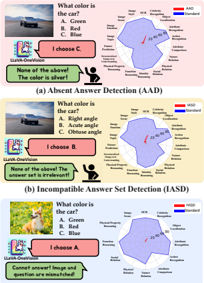

### Picture 2 (size: (423, 180))

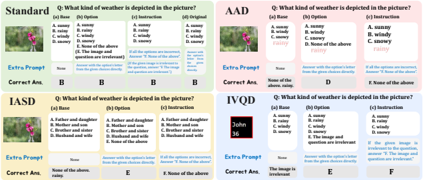

### Picture 3 (size: (228, 153))

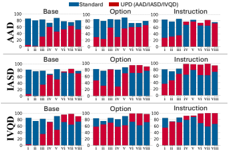

### Picture 4 (size: (399, 200))

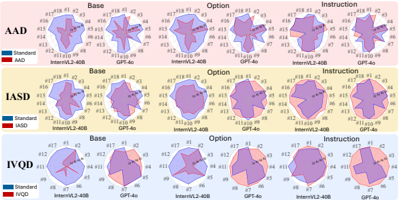

### Picture 5 (size: (147, 108))

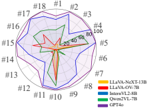

In [10]:
# Show pictures/images extracted by Docling
from IPython.display import Image as IPImage
import io

pictures = list(result.document.pictures)
print(f"Number of pictures found by Docling: {len(pictures)}\n")

for idx, pic in enumerate(pictures[:5], start=1):
    img = pic.get_image(result.document)
    if img is not None:
        # Resize for notebook display while keeping aspect ratio
        max_width = 780
        if img.width > max_width:
            ratio = max_width / img.width
            img = img.resize((max_width, int(img.height * ratio)))
        # Convert PIL image to bytes for IPython display
        buf = io.BytesIO()
        img.save(buf, format="PNG")
        display(Markdown(f"### Picture {idx} (size: {img.size})"))
        display(IPImage(data=buf.getvalue()))


## VLM to Query Image Info

* `MLX-VLM` — Apple's own ML framework, built specifically for M-series chips, much faster than transformers + PyTorch's incomplete MPS-ops.

In [11]:
# ---- Install ----
!pip install -q mlx-vlm

# ---- Load model ----
from mlx_vlm import load, generate
from mlx_vlm.prompt_utils import apply_chat_template
from mlx_vlm.utils import load_config

model_path = "mlx-community/Qwen2-VL-7B-Instruct-8bit"  # MLX-quantized, runs great on M-series
model, processor = load(model_path)
config = load_config(model_path)

# ---- Query function ----
def query_image(image_path, question):
    formatted_prompt = apply_chat_template(
        processor, config, question, num_images=1
    )
    output = generate(
        model, processor, formatted_prompt, [image_path],
        max_tokens=256, temperature=0.0, verbose=False
    )
    return output

# ---- Save the pictures extracted by Docling above ----
import os
from pathlib import Path
from PIL import Image as PILImage

image_dir = Path("extracted_images")
image_dir.mkdir(parents=True, exist_ok=True)

# `pictures` and `result.document` come from the Docling extraction cell above
saved_paths = []
for idx, pic in enumerate(pictures, start=1):
    img = pic.get_image(result.document)
    if img is not None:
        save_path = image_dir / f"picture_{idx:03d}.png"
        # Ensure RGB before saving as PNG
        if img.mode in ("RGBA", "P"):
            img = img.convert("RGB")
        img.save(save_path, format="PNG")
        saved_paths.append(save_path)

print(f"Saved {len(saved_paths)} images to {image_dir}")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Saved 27 images to extracted_images


### Without Image Preprocessing

* Some images didn't get valid output is because of the image encoder fails to produce a valid embedding. This can be because the image is corrupted, an unusual color mode, extreme aspect ratio, or too small/too large for the processor's resolution logic, etc. The model doesn't error out, it just falls back to treating the image as if it barely has visual content, and text generation collapses into repeating the most locally-probable token over and over. 

In [12]:
# ---- Run VLM over the extracted images ----
question = "Describe what this image shows in detail. If it's a chart or table, extract the key data points."

def wrap_text(text, max_words_per_row=20):
    text = str(text)
    words = text.split()
    lines = []
    for i in range(0, len(words), max_words_per_row):
        lines.append(" ".join(words[i:i + max_words_per_row]))
    return "\n".join(lines)

results = {}
for path in sorted(saved_paths)[:5]:
    fname = path.name
    answer = query_image(str(path), question)
    results[fname] = answer
    print(f"\n=== {fname} ===\n{wrap_text(answer)}")


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_001.png ===
GenerationResult(text='The image image image image image image image image image image image image image image image image image image image
image image image image image image image image image image image image image image image image image image image image
image image image image image image image image image image image image image image image image image image image image
image image image image image image image image image image image image image image image image image image image image
image image image image image image image image image image image image image image image image image image image image
image image image image image image image image image image image image image image image image image image image image
image image image image image image image image image image image image image image image image image image image image
image image image image image image image image image image image image image image image image image image image 

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_002.png ===
GenerationResult(text='The image shows a person holding an umbrella. The person is wearing a hat and a jacket. The background is
green, suggesting that the person is outdoors.', token=151645, logprobs=array([-15.6562, -15.7969, -13.5312, ..., -22.8906, -22.8906, -22.8906], dtype=float16), prompt_tokens=133, generation_tokens=32, total_tokens=165, prompt_tps=615.3740575684869,
generation_tps=37.742738530565454, peak_memory=9.177570746, cached_tokens=0, finish_reason='stop', diffusion_canvas_tokens=0, diffusion_denoising_steps=0, diffusion_work_tokens=0, diffusion_canvas_tps=0.0, diffusion_work_tps=0.0, is_draft=False, draft_text='', text_already_printed=False, diffusion_step=0, diffusion_total_steps=0, diffusion_canvas_index=0, diffusion_block_complete=False)


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_003.png ===
GenerationResult(text='The image appears to be a bar chart with multiple groups and subgroups. The chart is divided into three main
categories: "Base," "Option," and "Instruction." Each category has three subgroups labeled "AAD," "IASSD," and "IVOD." The x-axis represents different time
intervals, while the y-axis represents a numerical value, likely a percentage or a score.\n\nHere is a detailed description of the
chart:\n\n### Chart Description:\n- **Title:** The chart does not have a visible title.\n- **X-Axis:** The x-axis is labeled with time intervals,
which are not explicitly mentioned but appear to be days or weeks.\n- **Y-Axis:** The y-axis is labeled with numerical values,
which are not explicitly mentioned but appear to be percentages or scores.\n- **Categories:**\n - **Base:** Represents the baseline performance or
data.\n - **Option:** Represents an alternative or modified performance or data.\n - **Instruction:** Represents a performance or data w

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_004.png ===
GenerationResult(text='TheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheThe', token=785, logprobs=array([-16.9062, -17.5469, -13.1719, ..., -25.9844, -25.9844, -25.9844], dtype=float16), prompt_tokens=141, generation_tokens=256, total_tokens=397, prompt_tps=6

### Try Normalize Images to Improve Output

* Forces RGB color mode
  * Docling-saved PNGs are already RGB, but if an extracted image had palette (P) or RGBA modes, this prevents the processor from receiving an unexpected format
* Upscale tiny images to at least 56 px
  * Qwen2-VL works on a 28×28 patch grid. 56 px = 2×2 patches, which is roughly the minimum meaningful input.
  * If Docling extracts a very small icon or thumbnail, upscaling gives the vision encoder enough pixels to produce a non-degenerate embedding.
* Saves into a temporary PNG

In [14]:
from PIL import Image
import os

def preprocess_image(image_path, min_size=56):
    img = Image.open(image_path).convert("RGB")  # force RGB, drops alpha/palette issues
    w, h = img.size
    if w < min_size or h < min_size:
        # upscale tiny images so the processor has enough pixels to patch
        scale = min_size / min(w, h)
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    return img

def query_image(image_path, question):
    img = preprocess_image(image_path)
    tmp_path = "/tmp/_tmp_img.png"
    img.save(tmp_path)

    formatted_prompt = apply_chat_template(processor, config, question, num_images=1)
    output = generate(
        model, processor, formatted_prompt, [tmp_path],
        max_tokens=256, temperature=0.0, verbose=False
    )
    return output

# ---- Re-run VLM over the top 5 extracted images with normalization ----
question = "Describe what this image shows in detail. If it's a chart or table, extract the key data points."

normalized_results = {}
for path in sorted(saved_paths)[:5]:
    fname = path.name
    answer = query_image(str(path), question)
    normalized_results[fname] = answer
    print(f"\n=== {fname} (normalized) ===\n{wrap_text(answer)}")


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_001.png (normalized) ===
GenerationResult(text='The color is green.', token=151645, logprobs=array([-13.5, -14.4375, -14.2969, ..., -19.0156, -19.0156, -19.0156], dtype=float16), prompt_tokens=113, generation_tokens=6, total_tokens=119, prompt_tps=115.7602698318335, generation_tps=43.38884997070126, peak_memory=9.209193266, cached_tokens=0,
finish_reason='stop', diffusion_canvas_tokens=0, diffusion_denoising_steps=0, diffusion_work_tokens=0, diffusion_canvas_tps=0.0, diffusion_work_tps=0.0, is_draft=False, draft_text='', text_already_printed=False, diffusion_step=0, diffusion_total_steps=0, diffusion_canvas_index=0, diffusion_block_complete=False)


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_002.png (normalized) ===
GenerationResult(text='The image shows a person holding an umbrella. The person is wearing a hat and a jacket. The background is
green, suggesting that the person is outdoors.', token=151645, logprobs=array([-15.6562, -15.7969, -13.5312, ..., -22.8906, -22.8906, -22.8906], dtype=float16), prompt_tokens=133, generation_tokens=32, total_tokens=165, prompt_tps=617.6591299490321,
generation_tps=37.65468203630556, peak_memory=9.209193266, cached_tokens=0, finish_reason='stop', diffusion_canvas_tokens=0, diffusion_denoising_steps=0, diffusion_work_tokens=0, diffusion_canvas_tps=0.0, diffusion_work_tps=0.0, is_draft=False, draft_text='', text_already_printed=False, diffusion_step=0, diffusion_total_steps=0, diffusion_canvas_index=0, diffusion_block_complete=False)


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_003.png (normalized) ===
GenerationResult(text='The image appears to be a bar chart with multiple groups and subgroups. The chart is divided into three main
categories: "Base," "Option," and "Instruction." Each category has three subgroups labeled "AAD," "IASSD," and "IVOD." The x-axis represents different time
intervals, while the y-axis represents a numerical value, likely a percentage or a score.\n\nHere is a detailed description of the
chart:\n\n### Chart Description:\n- **Title:** The chart does not have a visible title.\n- **X-Axis:** The x-axis is labeled with time intervals,
which are not explicitly mentioned but appear to be days or weeks.\n- **Y-Axis:** The y-axis is labeled with numerical values,
which are not explicitly mentioned but appear to be percentages or scores.\n- **Categories:**\n - **Base:** Represents the baseline performance or
data.\n - **Option:** Represents an alternative or modified performance or data.\n - **Instruction:** Represents a performa

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_004.png (normalized) ===
GenerationResult(text='TheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheThe', token=785, logprobs=array([-16.9062, -17.5469, -13.1719, ..., -25.9844, -25.9844, -25.9844], dtype=float16), prompt_tokens=141, generation_tokens=256, total_tokens=397,

### Try Balanced Image Scaling to Improve Output

* Forces RGB color mode
* Upscale tiny images to at least 56 px on the short side
* Downscale very large images so the long side is at most 896 px
  * Without this, huge images create too many patches, which can overwhelm a 7B model and cause repetitive/degenerate output.
  * 896 px keeps memory and prompt length reasonable while preserving enough detail for charts and figures.
* Rounds width and height to multiples of 28
  * Qwen2-VL's patch grid expects dimensions divisible by 28.
  * Rounding avoids awkward padding/cropping by the processor and keeps the embedding grid clean.

In [16]:
from PIL import Image

def preprocess_balanced_image(image_path, min_dim=56, max_dim=896):
    img = Image.open(image_path).convert("RGB")  # force RGB, drops alpha/palette issues
    w, h = img.size

    # Upscale tiny images so the processor has enough patches
    if min(w, h) < min_dim:
        scale = min_dim / min(w, h)
        w = int(w * scale)
        h = int(h * scale)

    # Downscale very large images so the 7B model doesn't degenerate
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        w = int(w * scale)
        h = int(h * scale)

    # Round to multiples of 28 for Qwen2-VL patch grid
    w = max(min_dim, (w // 28) * 28)
    h = max(min_dim, (h // 28) * 28)

    return img.resize((w, h), Image.LANCZOS)

def query_image_balanced(image_path, question):
    img = preprocess_balanced_image(image_path)
    tmp_path = "/tmp/_tmp_img_balanced.png"
    img.save(tmp_path)

    formatted_prompt = apply_chat_template(processor, config, question, num_images=1)
    output = generate(
        model, processor, formatted_prompt, [tmp_path],
        max_tokens=256, temperature=0.0, verbose=False
    )
    return output

# ---- Re-run VLM over the top 5 extracted images with balanced preprocessing ----
question = "Describe what this image shows in detail. If it's a chart or table, extract the key data points."

balanced_results = {}
for path in sorted(saved_paths)[:5]:
    fname = path.name
    answer = query_image_balanced(str(path), question)
    balanced_results[fname] = answer
    print(f"\n=== {fname} (balanced) ===\n{wrap_text(answer)}")


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_001.png (balanced) ===
GenerationResult(text='The image consists of two main sections, labeled (a) and (b), each containing a visual representation and a textual explanation.\n\n###
Section (a): Absent Answer Detection (AAD)\n- **Visual Representation**: The image shows a map with a question mark in the center.
The map is divided into three regions, each labeled with a different color: green, blue, and red.\n- **Textual Explanation**: The
text explains that the question is "What color is the car?" and the answer choices are "A. Green," "B. Blue,"
and "C. Red." The user selects "C. Red."\n- **Answer Set**: The correct answer set is shown as "A. Green" and
"B. Blue."\n- **Outcome**: The image highlights that the user\'s answer "C. Red" is absent from the provided answer set.\n\n### Section
(b): Incompatible Answer Set Detection (IAD)\n- **Visual Representation**: Similar to section (a), this section also shows a map with a
question mark in the center. The map is divided into

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_002.png (balanced) ===
GenerationResult(text='The image shows a series of questions and answers related to weather conditions. The questions are presented in a grid
format, with each question having multiple options to choose from. The answers are also provided in a grid format, with
each answer having a corresponding label.\n\nThe questions are divided into four categories: Standard, AAD, IASD, and IVQD. Each category has
a different set of questions and answers.\n\nThe questions are about the type of weather depicted in the picture. The options
for each question include "rainy," "sunny," "cloudy," "windy," and "none of the above." The correct answers are also provided for
each question.\n\nThe grid format makes it easy to compare the questions and answers, and the different categories allow for a
more detailed analysis of the weather conditions depicted in the pictures.', token=151645, logprobs=array([-18.9375, -20.7188, -18.5312, ..., -25.3594, -25.3594, -25.3594], dtyp

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_003.png (balanced) ===
GenerationResult(text='The image appears to be a bar chart with multiple categories and subcategories. The chart is divided into three main
sections, each representing a different category: "Base," "Option," and "Instruction." Each section contains three subcategories: "AAD," "IASSD," and "IVOD."\n\n### Key
Data Points:\n\n1. **Base Category:**\n - **AAD:** The bar for "Base" in the "AAD" category is the highest among the three
subcategories.\n - **IASSD:** The bar for "Base" in the "IASSD" category is the second highest.\n - **IVOD:** The bar for
"Base" in the "IVOD" category is the lowest.\n\n2. **Option Category:**\n - **AAD:** The bar for "Option" in the "AAD" category
is the second highest.\n - **IASSD:** The bar for "Option" in the "IASSD" category is the highest.\n - **IVOD:** The
bar for "Option" in the "IVOD" category is the second highest.\n\n3. **Instruction Category:**\n - **AAD:** The bar for "Instruction" in
the "AAD" category is the lo

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



=== picture_004.png (balanced) ===
GenerationResult(text='TheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheTheThe', token=785, logprobs=array([-16.7969, -17.5156, -13.0703, ..., -25.9531, -25.9531, -25.9531], dtype=float16), prompt_tokens=141, generation_tokens=256, total_tokens=397, p

In [ ]:
# to-do: anyn solution for image 4?